In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


# Carregar os dataframes
df_regclim = pd.read_csv("/Users/biancarius/Desktop/CAETE-DVM-alloc-allom-including_alloc2_Cm2/scripts/yearly_mean_tables/MAN_regularclimate_yearly.csv")
df_2y = pd.read_csv("/Users/biancarius/Desktop/CAETE-DVM-alloc-allom-including_alloc2_Cm2/scripts/yearly_mean_tables/MAN_30prec_2y_yearly.csv")
df_4y = pd.read_csv("/Users/biancarius/Desktop/CAETE-DVM-alloc-allom-including_alloc2_Cm2/scripts/yearly_mean_tables/MAN_30prec_4y_yearly.csv")
df_6y = pd.read_csv("/Users/biancarius/Desktop/CAETE-DVM-alloc-allom-including_alloc2_Cm2/scripts/yearly_mean_tables/MAN_30prec_6y_yearly.csv")
df_8y = pd.read_csv("/Users/biancarius/Desktop/CAETE-DVM-alloc-allom-including_alloc2_Cm2/scripts/yearly_mean_tables/MAN_30prec_8y_yearly.csv")



In [5]:
# Variables of interest
variables = ['npp', 'ctotal', 'evapm', 'ls']

# Mapping variable names to plot labels
variables_label = {
    'npp': 'NPP',
    'ctotal': 'Total Carbon',
    'evapm': 'Evapotranspiration',
    'ls': 'Num. PLSs'
}

# Compute relative differences (%) with respect to the regular climate scenario
for var in variables:
    df_2y[var + '_diff_relative'] = (
        (df_2y[var] - df_regclim[var]) / df_regclim[var]
    ) * 100

    df_4y[var + '_diff_relative'] = (
        (df_4y[var] - df_regclim[var]) / df_regclim[var]
    ) * 100

    df_6y[var + '_diff_relative'] = (
        (df_6y[var] - df_regclim[var]) / df_regclim[var]
    ) * 100

    df_8y[var + '_diff_relative'] = (
        (df_8y[var] - df_regclim[var]) / df_regclim[var]
    ) * 100


In [6]:
# Create simulation year (starting at 0)
df_regclim['sim_year'] = range(len(df_regclim))
df_2y['sim_year'] = range(len(df_2y))
df_4y['sim_year'] = range(len(df_4y))
df_6y['sim_year'] = range(len(df_6y))
df_8y['sim_year'] = range(len(df_8y))


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# Colors (colorblind-friendly)
# -----------------------------
colors = {
    "npp":    "#3B5BA9",  # blue
    "ctotal": "#2A9D8F",  # teal
    "evapm":  "#8C2D3E",  # wine
    "ls":     "#B58900",  # mustard
}

# -----------------------------
# Scenario dataframes (already prepared)
# -----------------------------
scenarios = {
    "every 2y": df_2y,
    "every 4y": df_4y,
    "every 6y": df_6y,
    "every 8y": df_8y,
}

# Desired plotting order + display labels
order = ["every 8y", "every 6y", "every 4y", "every 2y"]
title_map = {
    "every 8y": "Reduced precipitation: every 8 years",
    "every 6y": "Reduced precipitation: every 6 years",
    "every 4y": "Reduced precipitation: every 4 years",
    "every 2y": "Reduced precipitation: every 2 years",
}

sns.set_style("white")

fig, axes = plt.subplots(
    nrows=2, ncols=2,
    figsize=(12, 7),
    sharex=True, sharey=True
)
axes = axes.flatten()

# -----------------------------
# Helper: drought barcode (top + bottom)
# -----------------------------
def add_drought_barcode(ax, drought_sim_years, height=0.04, color="0.2",
                        alpha_bottom=0.08, alpha_top=0.08):
    for y in drought_sim_years:
        # bottom strip
        ax.axvspan(
            y - 0.5, y + 0.5,
            ymin=0.0, ymax=height,
            color=color, alpha=alpha_bottom,
            lw=0, zorder=0
        )
        # top strip
        ax.axvspan(
            y - 0.5, y + 0.5,
            ymin=1.0 - height, ymax=1.0,
            color=color, alpha=alpha_top,
            lw=0, zorder=0
        )

# Max x for ticks
max_year = int(df_regclim["sim_year"].max())

# -----------------------------
# Draw panels
# -----------------------------
for ax, sc_name in zip(axes, order):
    df_sc = scenarios[sc_name]

    # drought years: sim_year=0 normal, first drought at sim_year=1, then every k years
    k = int(sc_name.split()[1].replace("y", ""))  # "every 4y" -> 4
    drought_sim_years = [y for y in range(0, max_year + 1) if (y >= 1 and (y - 1) % k == 0)]

    # make 2y extra subtle to avoid zebra
    alpha = 0.04 if k == 2 else 0.08
    add_drought_barcode(
        ax,
        drought_sim_years,
        height=0.04,
        color="0.2",
        alpha_bottom=alpha,
        alpha_top=alpha
    )

    # lines
    for var in variables:
        sns.lineplot(
            data=df_sc,
            x="sim_year",
            y=f"{var}_diff_relative",
            ax=ax,
            color=colors[var],
            linewidth=2.0,
            label=variables_label[var],
            zorder=2
        )

    # 0% reference line
    ax.axhline(0, color="black", linestyle="--", linewidth=1, zorder=1)

    # Title (with "years")
    ax.set_title(title_map[sc_name], fontsize=12)

    # Clean look
    ax.grid(False)
    sns.despine(ax=ax)

    # Remove per-axis legend
    if ax.get_legend() is not None:
        ax.legend_.remove()

    # Remove axis *labels* (so "sim_year" and "npp_diff_relative" never appear)
    ax.set_xlabel("")
    ax.set_ylabel("")
        # Force y axis to percentage scale
    ax.set_ylim(-100, 10)
    ax.set_yticks([0, -25, -50, -75, -100])
    ax.set_yticklabels(["0", "-25", "-50", "-75", "-100"])


# -----------------------------
# Common axis labels
# -----------------------------
fig.supxlabel("Simulation year", fontsize=13)
fig.supylabel("Change relative to regular climate (%)", fontsize=13)

# X ticks: 0, 5, 10, ...
for ax in axes:
    ax.set_xticks(range(0, max_year + 1, 5))

# -----------------------------
# One legend for the entire figure
# -----------------------------
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc="lower center",
    ncol=4,
    frameon=False,
    fontsize=11,
    bbox_to_anchor=(0.5, -0.02)
)

plt.tight_layout()
plt.subplots_adjust(bottom=0.12)
plt.show()


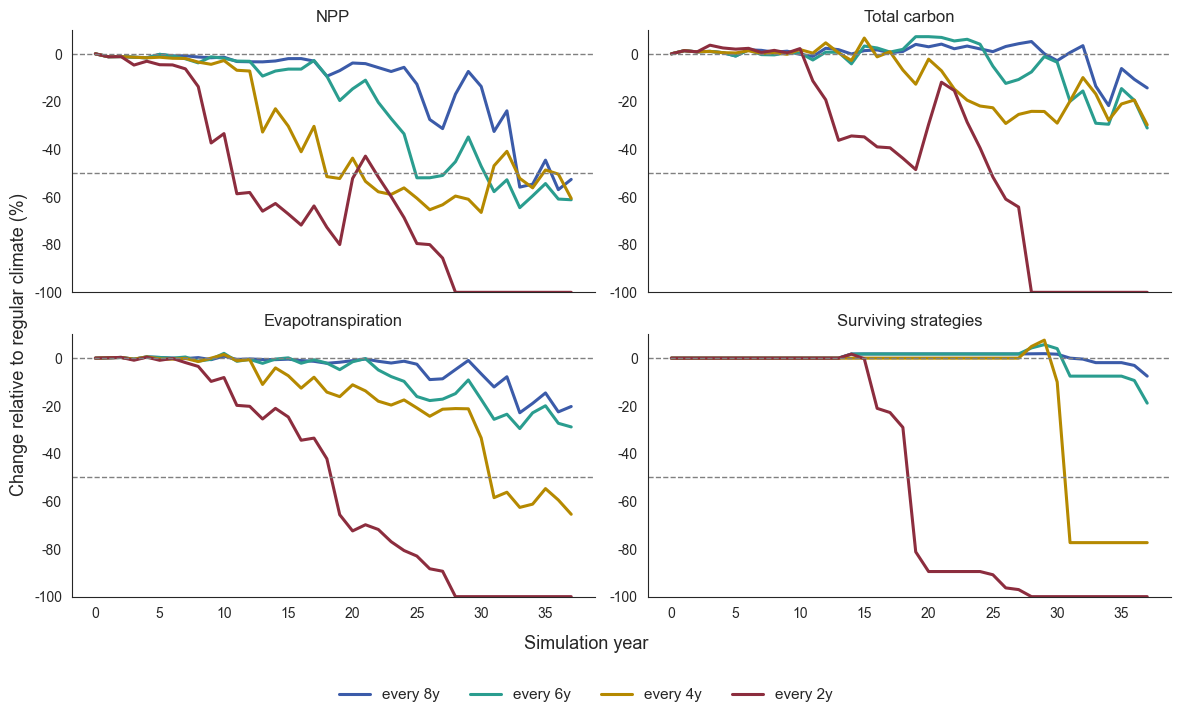

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# Scenario dataframes (already prepared)
# -----------------------------
# Assumes each dataframe already contains:
# - 'sim_year'
# - '{var}_diff_relative' columns for var in variables
scenarios = {
    "2y": df_2y,
    "4y": df_4y,
    "6y": df_6y,
    "8y": df_8y,
}

# Plot order (from least frequent drought to most frequent)
order = ["8y", "6y", "4y", "2y"]

# -----------------------------
# Variables and labels
# -----------------------------
variables = ["npp", "ctotal", "evapm", "ls"]
variables_label = {
    "npp": "NPP",
    "ctotal": "Total carbon",
    "evapm": "Evapotranspiration",
    "ls": "Surviving strategies",
}

# -----------------------------
# Frequency colors (user-specified)
# -----------------------------
freq_colors = {
    "8y": "#3B5BA9",  # blue
    "6y": "#2A9D8F",  # teal
    "4y": "#B58900",  # mustard
    "2y": "#8C2D3E",  # wine
}

# -----------------------------
# Plot settings (clean, Nature-like)
# -----------------------------
sns.set_style("white")

fig, axes = plt.subplots(
    nrows=2, ncols=2,
    figsize=(12, 7),
    sharex=True,
    sharey=False
)
axes = axes.flatten()

# Determine maximum simulation year for tick marks
max_year = int(df_regclim["sim_year"].max())

# -----------------------------
# Draw each variable in its own panel
# -----------------------------
for ax, var in zip(axes, variables):

    for sc in order:
        df_sc = scenarios[sc]

        sns.lineplot(
            data=df_sc,
            x="sim_year",
            y=f"{var}_diff_relative",
            ax=ax,
            linewidth=2.2,
            label=sc,
            color=freq_colors[sc],
        )

    ax.axhline(0, color="grey", linestyle="--", linewidth=1)
    ax.axhline(-50, color="grey", linestyle="--", linewidth=1)
    ax.set_title(variables_label[var], fontsize=12)
    ax.grid(False)
    sns.despine(ax=ax)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_ylim(-100, 0)
    ax.set_yticks([10, 0, -20, -40, -60, -80, -100])
    ax.set_yticklabels(["","0", "-20", "-40", "-60","-80",  "-100"])

    if ax.get_legend() is not None:
        ax.legend_.remove()


# -----------------------------
# Common axis labels
# -----------------------------
fig.supxlabel("Simulation year", fontsize=13, y=0.06)
fig.supylabel("Change relative to regular climate (%)", fontsize=13)

# X ticks: 0, 5, 10, ...
for ax in axes:
    ax.set_xticks(range(0, max_year + 1, 5))

# -----------------------------
# One shared legend (frequencies)
# -----------------------------
handles, labels = axes[0].get_legend_handles_labels()

# Make legend labels a bit more explicit (optional)
label_map = {"8y": "every 8y", "6y": "every 6y", "4y": "every 4y", "2y": "every 2y"}
labels = [label_map.get(l, l) for l in labels]

fig.legend(
    handles, labels,
    loc="lower center",
    ncol=4,
    frameon=False,
    fontsize=11,
    bbox_to_anchor=(0.5, -0.03)
)

plt.tight_layout()
plt.subplots_adjust(bottom=0.14)  # space for legend
plt.show()


